In [15]:
# embeddings semanticos com sentence-tranformers
"""
Objetivo: gerar vetores densos que capturam SIGNIFICADO,
e provar que frases similares ficam próximas no espaço vetorial
mesmo usando palavras completamente diferentes.
"""
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [16]:
# vamos usar frases com palavras com memso sentido e smenatic diferentes
# grupo A: frases sobre cachorro (mesmo significado palavras diferentes)
# grupo B: frases sobre tecnologia
# grupo C: frases sem contexto

frases = [
    "O cachorro correu pelo parque",
    "O cão foi embora correndo pelo jardim",
    "Um cão brincou no quintal",
    "Inteligência artificial está transformando o mundo",
    "Machine learning é uma área da IA",
    "Redes neurais aprendem com dados",
    "A receita de bolo leva farinha e ovos",
]

labels = ["cachorro-0", "cachorro-1", "cachorro-2",
          "tech-3", "tech-4", "tech-5", "comida-6"]

In [4]:
modelo = SentenceTransformer('all-MiniLM-L6-v2') # modelo leve treinado em bilhões de pares de frases

print("Modelo carregado:", modelo)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11024.69it/s]


Modelo carregado: SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)


In [17]:
#geracao de embeddings

# .encode() recebe uma lista de strings e retorna um array NumPy cada frase vira um vetor de 384 número
embeddings = modelo.encode(frases)

print(f"Shape dos embeddings: {embeddings.shape}")
# vai ser extraido (7: 384) 7 linhas = 7 frases, 384 colunas = 384 dimensoes de vetor

print(f"\nEmbedding da primeira frase (primeiros 10 valores):")
# Mostra os primeiros 10 números do vetor da frase "O cachorro correu pelo parque"
print(embeddings[0][:10].round(4))

Shape dos embeddings: (7, 384)

Embedding da primeira frase (primeiros 10 valores):
[-0.0312  0.0417 -0.0537 -0.0231 -0.1365 -0.019   0.0829  0.0257  0.0354
  0.0481]


In [18]:
# vamos calcular a similaridade cossenoidal
sim_embeddings = cosine_similarity(embeddings) # Calcula o score de similaridade entre os pares de frases.

# Converte a matriz de similaridade num DataFrame legível
df_sim_emb = pd.DataFrame(sim_embeddings, index = labels, columns = labels).round(3)

print("Matriz de similidade com sentence-tranformers")
print(df_sim_emb)

Matriz de similidade com sentence-tranformers
            cachorro-0  cachorro-1  cachorro-2  tech-3  tech-4  tech-5  \
cachorro-0       1.000       0.596       0.525   0.343   0.207   0.341   
cachorro-1       0.596       1.000       0.531   0.366   0.335   0.369   
cachorro-2       0.525       0.531       1.000   0.305   0.245   0.302   
tech-3           0.343       0.366       0.305   1.000   0.487   0.292   
tech-4           0.207       0.335       0.245   0.487   1.000   0.183   
tech-5           0.341       0.369       0.302   0.292   0.183   1.000   
comida-6         0.490       0.505       0.363   0.431   0.364   0.335   

            comida-6  
cachorro-0     0.490  
cachorro-1     0.505  
cachorro-2     0.363  
tech-3         0.431  
tech-4         0.364  
tech-5         0.335  
comida-6       1.000  


In [19]:
# Comparação direta: BoW vs TF-IDF vs Embeddings

# Recriando as matrizes para comparar lado a lado
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(frases)
sim_bow = cosine_similarity(X_bow)
df_sim_bow = pd.DataFrame(sim_bow, index=labels, columns=labels).round(3)

tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(frases)
sim_tfidf = cosine_similarity(X_tfidf)
df_sim_tfidf = pd.DataFrame(sim_tfidf, index=labels, columns=labels).round(3)

# Os mesmos pares críticos do Bloco npl agora com uma terceira coluna
pares_interesse = [
    ("cachorro-0", "cachorro-1", "Mesmo tema, palavras diferentes"),
    ("cachorro-0", "cachorro-2", "Mesmo tema, 1 palavra em comum"),
    ("tech-3",     "tech-4",     "Mesmo tema, algumas palavras em comum"),
    ("cachorro-0", "comida-6",   "Temas completamente diferentes"),
    ("tech-3",     "comida-6",   "Temas completamente diferentes"),
]

print("\n=== COMPARAÇÃO FINAL: BoW vs TF-IDF vs Embeddings ===\n")
print(f"{'Par':<45} {'BoW':>6} {'TF-IDF':>8} {'Emb':>8}")
print("-" * 75)

# Busca o score de cada metodo no DataFrame correspondente
for a, b, descricao in pares_interesse:
    score_bow    = df_sim_bow.loc[a, b]
    score_tfidf  = df_sim_tfidf.loc[a, b]
    score_emb    = df_sim_emb.loc[a, b]

# Agora vou exibir três colunas de score a terceira é o embedding
    print(f"{descricao:<45} {score_bow:>6.3f} {score_tfidf:>8.3f} {score_emb:>8.3f}")

print("\n✅ CONCLUSÃO:")
print("Embeddings detectam similaridade semântica REAL.")
print("Frases com mesmo significado, mesmo com palavras diferentes,")
print("agora ficam com scores altos porque o modelo aprendeu SIGNIFICADO.")


=== COMPARAÇÃO FINAL: BoW vs TF-IDF vs Embeddings ===

Par                                              BoW   TF-IDF      Emb
---------------------------------------------------------------------------
Mesmo tema, palavras diferentes                0.204    0.155    0.596
Mesmo tema, 1 palavra em comum                 0.000    0.000    0.525
Mesmo tema, algumas palavras em comum          0.000    0.000    0.487
Temas completamente diferentes                 0.000    0.000    0.490
Temas completamente diferentes                 0.000    0.000    0.431

✅ CONCLUSÃO:
Embeddings detectam similaridade semântica REAL.
Frases com mesmo significado, mesmo com palavras diferentes,
agora ficam com scores altos porque o modelo aprendeu SIGNIFICADO.


In [29]:
# agora vamos usar uma variacao maior de frases

frases = [
    # Grupo cachorro
    "O cachorro correu pelo parque",
    "O cão foi embora correndo pelo jardim",
    "Um cão brincou no quintal",
    "Meu cachorro late muito",
    "O cãozinho dormiu no sofá",

    # Grupo tecnologia/IA
    "Inteligência artificial está transformando o mundo",
    "Machine learning é uma área da IA",
    "Redes neurais aprendem com dados",
    "Deep learning usa múltiplas camadas",
    "Algoritmos de IA resolvem problemas complexos",

    # Grupo comida
    "A receita de bolo leva farinha e ovos",
    "O jantar estava delicioso",
    "Fiz uma massa com molho de tomate",
    "O bolo de chocolate ficou perfeito",
    "Cozinhar é uma arte criativa",
]

labels = [
    "cachorro-0", "cachorro-1", "cachorro-2", "cachorro-3", "cachorro-4",
    "tech-0",     "tech-1",     "tech-2",     "tech-3",     "tech-4",
    "comida-0",   "comida-1",   "comida-2",   "comida-3",   "comida-4",
]

# cores para cada grupo, usamos nos graficos para conseguir diferenciar
cores = (
    ["#2196F3"] * 5 +   # azul para cachorro
    ["#4CAF50"] * 5 +   # verde para tech
    ["#FF5722"] * 5     # laranja para comida
)
print(f"Total de frases: {len(frases)}")

Total de frases: 15


In [30]:
# vamos carregar o modelo
modelo = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = modelo.encode(frases) # vamos gerar a matriz (15,384)

print(f"Shape dos embeddings: {embeddings.shape}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9267.29it/s]


Shape dos embeddings: (15, 384)


In [31]:
# reducao com PCA, abordagem linear
# Cria o objeto PCA configurado para comprimir até 2 dimensões.
pca = PCA(n_components=2)

# fit aprende as direções de maior variância nos 384 dims
embeddings_pca = pca.fit_transform(embeddings)

print(f"Shape após PCA: { embeddings_pca.shape}")
# Mostra quanto da informação original foi preservada na compressão.
# x% significa que os 2 componentes capturam 45% da variância total.
# Quanto mais alto, melhor a PCA conseguiu representar os dados em 2D.
print(f"Variacia explicada pelos 2 componentes: { pca.explained_variance_ratio_.sum():.2%}")

Shape após PCA: (15, 2)
Variacia explicada pelos 2 componentes: 29.19%


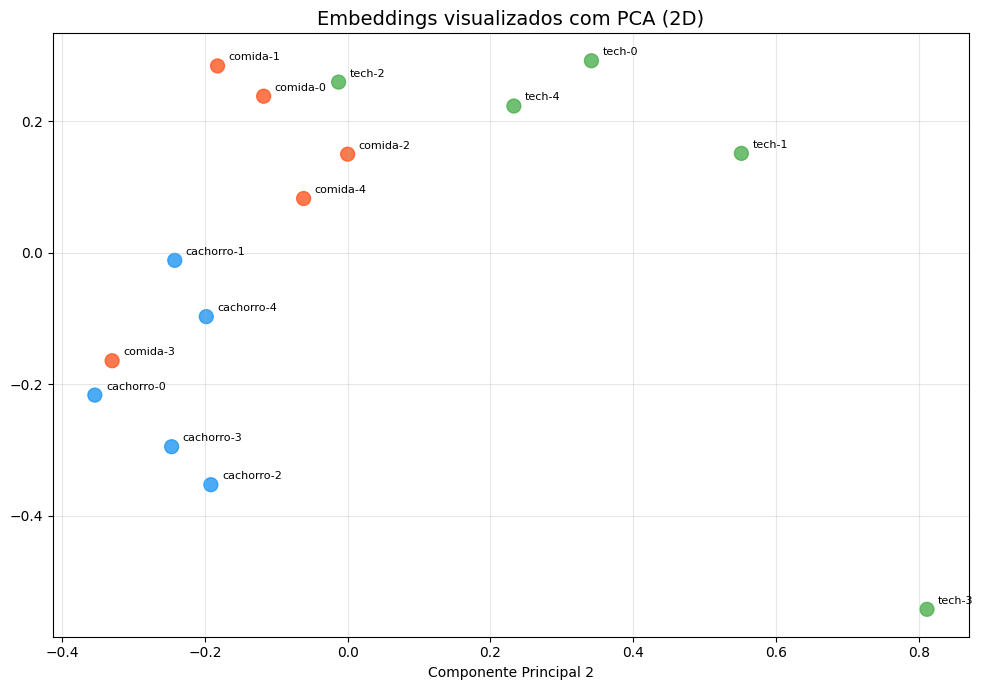

In [32]:
# platagem do grafico PCA
# Cria uma figura de 10×7 polegadas
plt.figure(figsize=(10,7))

plt.scatter(
    embeddings_pca[:,0], # coordenada X de cada ponto (1º componente principal)
    embeddings_pca[:,1], # coordenada Y de cada ponto (2º componente principal)
    c=cores,             # cor de cada ponto conforme o grupo
    s=100,               # tamanho dos pontos
    alpha=0.8            # leve transparência para sobreposições ficarem visíveis
)

for i, label in enumerate(labels):
    plt.annotate(
        label,
        (
        embeddings_pca[i,0],        # texto a exibir
        embeddings_pca[i,1]),       # posição X do texto
        textcoords="offset points", # posição Y do texto
        xytext=(8,4), # coordenadas relativas ao ponto
        fontsize=8 # tamanho da fonte
    )

plt.title("Embeddings visualizados com PCA (2D)", fontsize=14)
plt.xlabel("Componente Principal 1")
plt.xlabel("Componente Principal 2")
# Grid sutil para facilitar a leitura das posições
plt.grid(True, alpha=0.3)

# Ajusta margens automaticamente para nada ficar cortado
plt.tight_layout()
plt.show()

In [41]:
# reducao com UMAP, abordagem não-linear

reducer = umap.UMAP(
    n_components=2,     # comprimir para 2 dimensões
    # valor baixo preserva estrutura muito local (clusters tight) e # valor alto global
    n_neighbors=5, # quantos vizinhos locais considerar no mapa
    min_dist=0.3, # distância mínima entre pontos no espaço 2D
    random_state=42 # semente para reproducibilidade e grafico toda vez que rodar
)
# Aprende a estrutura local dos 384 dims e projeta em 2D
embeddings_umap = reducer.fit_transform(embeddings)

print(f"Shape após UMAP: {embeddings_umap.shape}")

Shape após UMAP: (15, 2)


/home/gabriel-anthony/DESENVOLVIMENTO/DATA-SCIENCE/ML-Pipeline/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


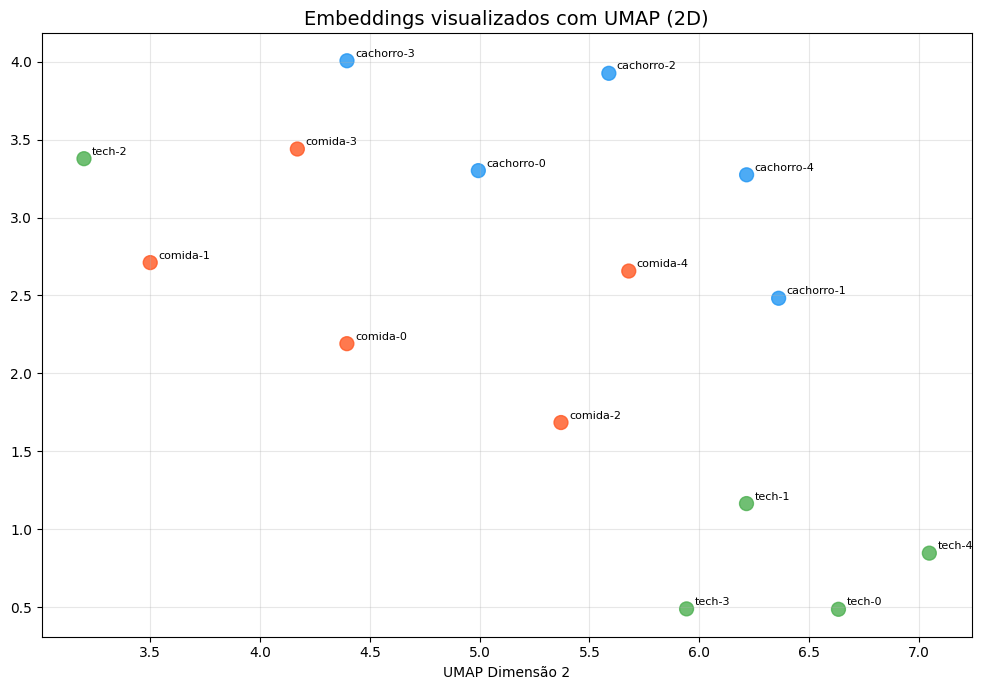

In [47]:
# plotanod o grafico de UMPA

plt.figure(figsize=(10,7))

plt.scatter(
    embeddings_umap[:,0],
    embeddings_umap[:,1],
    c=cores,
    s=100,
    alpha=0.8
)

for i, label in enumerate(labels):
    plt.annotate(
        label,
        (embeddings_umap[i,0], embeddings_umap[i,1]),
        textcoords="offset pixels",
        xytext=(8,4),
        fontsize=8
    )

plt.title("Embeddings visualizados com UMAP (2D)", fontsize=14)
plt.xlabel("UMAP Dimensão 1")
plt.xlabel("UMAP Dimensão 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()